In [1]:
from src.data_loading import (
    TARGET_COL,
    ID_COL,
    load_data,
    train_valid_split,
)
from src.models import make_logistic_regression, make_random_forest, make_lightGBM, evaluate_roc_auc

application_train, application_test = load_data()
X_train, X_valid, y_train, y_valid = train_valid_split(application_train)
logistic_regression_model = make_logistic_regression()
random_forest_model = make_random_forest()
lgbm_model = make_lightGBM()


In [4]:
import pandas as pd

logistic_roc_auc_score = evaluate_roc_auc(logistic_regression_model, X_train, X_valid, y_train, y_valid)
random_forest_roc_auc_score = evaluate_roc_auc(random_forest_model, X_train, X_valid, y_train, y_valid)
lgbm_model_roc_auc_score = evaluate_roc_auc(lgbm_model, X_train, X_valid, y_train, y_valid)

baseline_results = pd.DataFrame(
    {
        "model": ["Logistic Regression", "Random Forest", "LightGBM"],
        "roc_auc": [
            logistic_roc_auc_score,
            random_forest_roc_auc_score,
            lgbm_model_roc_auc_score,
        ],
    }
).sort_values("roc_auc", ascending=False)

baseline_results

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052996 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12841
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 299
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000


/Users/ryanyao/Quant Projects/Home_Credit/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,roc_auc
2,LightGBM,0.767204
0,Logistic Regression,0.750637
1,Random Forest,0.750563


/Users/ryanyao/Quant Projects/Home_Credit/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


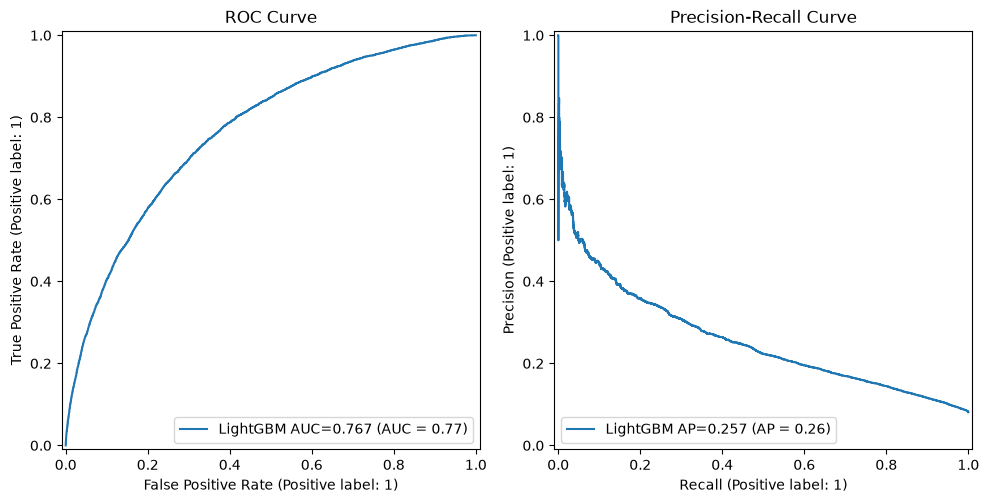

In [3]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, roc_auc_score, average_precision_score

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
valid_pred = lgbm_model.predict_proba(X_valid)[:, 1]
roc_auc = roc_auc_score(y_valid, valid_pred)
avg_precision = average_precision_score(y_valid, valid_pred)

RocCurveDisplay.from_predictions(
    y_valid,
    valid_pred,
    ax=axes[0],
    name=f"LightGBM AUC={roc_auc:.3f}",
)

PrecisionRecallDisplay.from_predictions(
    y_valid,
    valid_pred,
    ax=axes[1],
    name=f"LightGBM AP={avg_precision:.3f}",
)

axes[0].set_title("ROC Curve")
axes[1].set_title("Precision-Recall Curve")

plt.tight_layout()
plt.show()
